In [1]:
import sys, os
import scipy.io as sio
import json

from resmem import ResMem, transformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from scipy.stats import pearsonr, spearmanr, false_discovery_control, ttest_1samp

import warnings
warnings.filterwarnings("ignore")

from mne.parallel import parallel_func


In [2]:
ROI_LABELS = ["LO", "PFS", "PPA", "RSC", "OPA", 
              "headbody", "tail", "PRC", "EVC",] 
            #   "PHCminusPPA", "subiculum", "DG", "CA1", "CA3"]

PHASE_LIST = ["E", "R"]
ITEM_LIST = [
             "drill", "hairbrush", "wateringcan",
             "bowl", "cupcake", "flowers",
             "guitar", "leafblower", "umbrella",
             "chair", "lamppost", "tv",
             "garden", "lake", "mountains",
             "city", "farmhouse", "suburbs",
             "bathroom", "conferencehall", "livingroom",
             "cave", "forestccanopy", "icecave",
             ]

# Memorability

## Pre-trained Resmem

In [3]:
# pre-defined levels
coarse_level = ["objects", "scenes"]
high_level = ["small", "big", "open", "closed"]
mid_level = ["nottool", "tool", "natural", "manmade"]
low_level = ["drill", "hairbrush", "wateringcan", 
             "flowers", "cupcake", "bowl", 
             "umbrella", "leafblower", "guitar",
             "tv", "lamppost", "chair",
             "mountains", "lake", "garden",
             "suburbs", "city", "farmhouse",
             "icecave", "forestccanopy", "cave",
             "livingroom", "conferencehall", "bathroom"]

object_list = ["drill", "hairbrush", "wateringcan", 
               "flowers", "cupcake", "bowl", 
               "umbrella", "leafblower", "guitar",
               "tv", "lamppost", "chair"]

In [3]:
# load model
model = ResMem(pretrained=True)
# initialize dataframe to store memorability scores for each image
mem_df = pd.DataFrame(columns=["category", "image", "mem_score"])

# get memorability score for every image
img_path = "./images/"

for root, dirs, files in os.walk(img_path):
    for file in files:
        if file.endswith(".jpg"):
            # get image file            
            file_category = root.split("/")[-1]
            img = Image.open(os.path.join(root, file))
            img = img.convert("RGB")
            # get memorability score
            model.eval()
            image_x = transformer(img)
            prediction = model(image_x.view(-1, 3, 227, 227))
            mem_score = prediction.item()
            # save in dataframe
            mem_df.loc[len(mem_df)] = [file_category, file, mem_score]

/Users/leochang/miniforge3/envs/py310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/leochang/miniforge3/envs/py310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [6]:
mem_df

,category,image,mem_score
0,opennaturalmountains,mountains16.jpg,0.491384
1,opennaturalmountains,mountains14.jpg,0.470827
2,opennaturalmountains,mountains10.jpg,0.467255
3,opennaturalmountains,mountains11.jpg,0.676096
4,opennaturalmountains,mountains12.jpg,0.566821
...,...,...,...
187,bignottoollamppost,lamppost5.jpg,0.879278
188,bignottoollamppost,lamppost7.jpg,0.763000
189,bignottoollamppost,lamppost16.jpg,0.880247
190,bignottoollamppost,lamppost15.jpg,0.850027


In [ ]:
# extract category information
def get_category(row, category_list):
    curr_label = row["category"]
    for category in category_list:
        if category in curr_label:
            return category
        
mem_df["high_level"] = mem_df.apply(get_category, args=(high_level,), axis=1)
mem_df["mid_level"] = mem_df.apply(get_category, args=(mid_level,), axis=1)
mem_df["fine_level"] = mem_df.apply(get_category, args=(low_level,), axis=1)
mem_df["coarse_level"] = mem_df["fine_level"].apply(lambda x: "object" if x in object_list else "scene")
# save data
mem_df.to_csv("./data/mem_df.csv")

In [4]:
# load saved data
mem_df = pd.read_csv("./data/mem_df.csv")
mem_df

,Unnamed: 0.1,Unnamed: 0,category,image,mem_score,high_level,mid_level,fine_level,coarse_level
0,0,0,opennaturalmountains,mountains16.jpg,0.491384,open,natural,mountains,scene
1,1,1,opennaturalmountains,mountains14.jpg,0.470827,open,natural,mountains,scene
2,2,2,opennaturalmountains,mountains10.jpg,0.467255,open,natural,mountains,scene
3,3,3,opennaturalmountains,mountains11.jpg,0.676096,open,natural,mountains,scene
4,4,4,opennaturalmountains,mountains12.jpg,0.566821,open,natural,mountains,scene
...,...,...,...,...,...,...,...,...,...
187,187,187,bignottoollamppost,lamppost5.jpg,0.879278,big,nottool,lamppost,object
188,188,188,bignottoollamppost,lamppost7.jpg,0.763000,big,nottool,lamppost,object
189,189,189,bignottoollamppost,lamppost16.jpg,0.880247,big,nottool,lamppost,object
190,190,190,bignottoollamppost,lamppost15.jpg,0.850027,big,nottool,lamppost,object


## Memorability Scores

### Fine Level

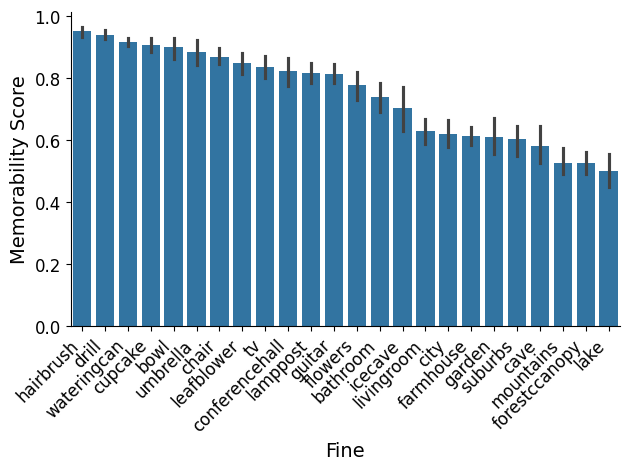

In [5]:
# sort by descending order
result = mem_df.groupby(["fine_level"])\
               .agg({"mem_score": "mean"})\
               .reset_index()\
               .sort_values("mem_score", ascending=False)

# plot by fine level
ax = plt.subplot(111)
sns.barplot(data=mem_df,
            x="fine_level",
            y="mem_score",
            order=result["fine_level"],
            ax=ax)

plt.xlabel("Fine", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Memorability Score", fontsize=14)
plt.tick_params(labelsize=12)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### Mid Level

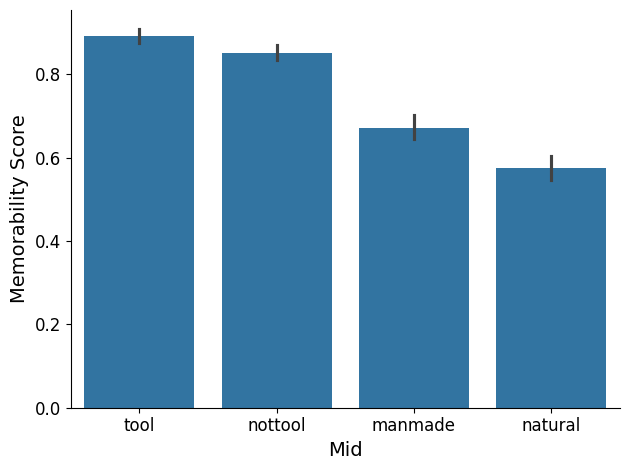

In [6]:
# sort by descending order
result = mem_df.groupby(["mid_level"])\
               .agg({"mem_score": "mean"})\
               .reset_index()\
               .sort_values("mem_score", ascending=False)

# plot by fine level
ax = plt.subplot(111)
sns.barplot(data=mem_df,
            x="mid_level",
            y="mem_score",
            order=result["mid_level"],
            ax=ax)

plt.xlabel("Mid", fontsize=14)
plt.tick_params(labelsize=12)
plt.ylabel("Memorability Score", fontsize=14)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### High Level

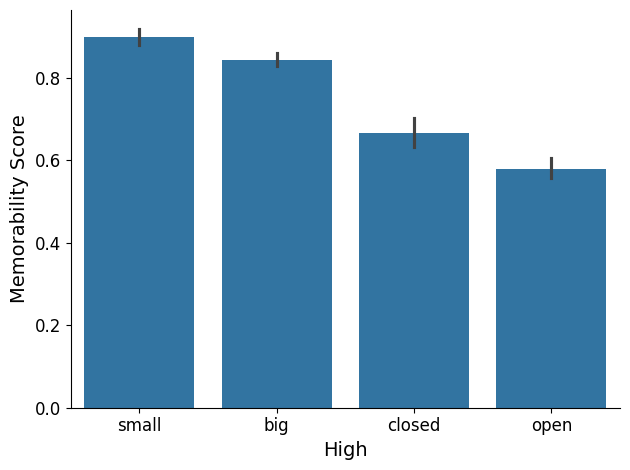

In [7]:
# sort by descending order
result = mem_df.groupby(["high_level"])\
               .agg({"mem_score": "mean"})\
               .reset_index()\
               .sort_values("mem_score", ascending=False)

# plot by fine level
ax = plt.subplot(111)
sns.barplot(data=mem_df,
            x="high_level",
            y="mem_score",
            order=result["high_level"],
            ax=ax)

plt.xlabel("High", fontsize=14)
plt.tick_params(labelsize=12)
plt.ylabel("Memorability Score", fontsize=14)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### Coarse Level

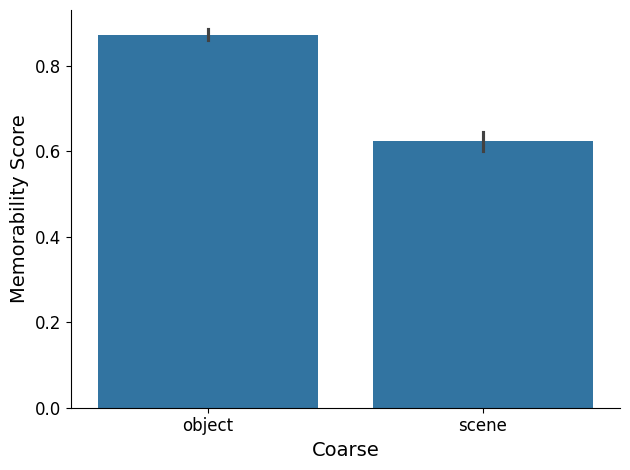

In [8]:
# sort by descending order
result = mem_df.groupby(["coarse_level"])\
               .agg({"mem_score": "mean"})\
               .reset_index()\
               .sort_values("mem_score", ascending=False)

# plot by fine level
ax = plt.subplot(111)
sns.barplot(data=mem_df,
            x="coarse_level",
            y="mem_score",
            order=result["coarse_level"],
            ax=ax)

plt.xlabel("Coarse", fontsize=14)
plt.tick_params(labelsize=12)
plt.ylabel("Memorability Score", fontsize=14)
plt.tick_params(labelsize=12)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### Aggregate

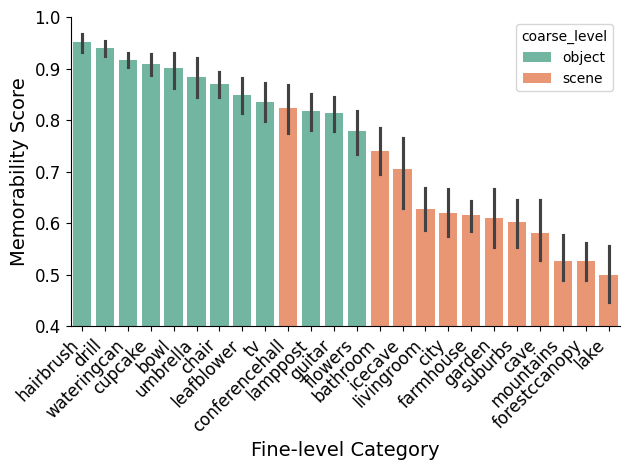

In [14]:
# sort by descending order
result = mem_df.groupby(["fine_level"])\
               .agg({"mem_score": "mean"})\
               .reset_index()\
               .sort_values("mem_score", ascending=False)

# plot by fine level
ax = plt.subplot(111)
sns.barplot(data=mem_df,
            x="fine_level",
            y="mem_score",
            order=result["fine_level"],
            hue="coarse_level",
            hue_order=["object", "scene"],
            palette="Set2",
            ax=ax)

plt.xlabel("Fine-level Category", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Memorability Score", fontsize=14)
plt.ylim([0.4,1])
plt.tick_params(labelsize=12)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

# Pre-processing

In [26]:
sub_list = np.arange(1, 23)
roi_list = []
cond_list = []
odd_dict = {}
even_dict = {}

SAVED = os.path.exists("./data/roi_df.csv") | os.path.exists("./data/cond_df.csv")

for sub in sub_list:
    # load subject data
    sub_data = sio.loadmat(f"./fMRI_data/sub{sub}data.mat")

    if not SAVED:
        # ROI coordinates
        sub_roi = sub_data["ROIcoordinates"][0,0]
        for roi in ROI_LABELS:
            try:
                sub_roi_data = sub_roi[roi]
            except:
                continue
            sub_roi_df = pd.DataFrame(sub_roi_data, columns=["x", "y", "z"])
            sub_roi_df["sub"] = sub
            sub_roi_df["roi"] = roi
            roi_list.append(sub_roi_df)

        # conditions
        sub_conds = sub_data["conditionNames"]
        sub_cond_list = []
        for i in range(sub_conds.shape[0]):
            sub_cond_list.append(sub_conds[i][0][0])

        sub_cond_df = pd.DataFrame(sub_cond_list, columns=["category"])
        sub_cond_df["sub"] = sub
        cond_list.append(sub_cond_df)

    # odd-trial brain data
    sub_odd_data = sub_data["oddBrainData"]
    odd_dict[int(sub)] = sub_odd_data

    # even-trial brain data
    sub_even_data = sub_data["evenBrainData"]
    even_dict[int(sub)] = sub_even_data
    
# now concatenate all
if SAVED:
    roi_df = pd.read_csv("./data/roi_df.csv")
    cond_df = pd.read_csv("./data/cond_df.csv")
else:
    roi_df = pd.concat(roi_list, ignore_index=True)
    cond_df = pd.concat(cond_list, ignore_index=True)
    # phase (Encoding, Distractor, Recall)
    cond_df["phase"] = cond_df["category"].apply(lambda x: x[0])
    # category
    cond_df["high_level"] = cond_df.apply(get_category, args=(high_level,), axis=1)
    cond_df["mid_level"] = cond_df.apply(get_category, args=(mid_level,), axis=1)
    cond_df["fine_level"] = cond_df.apply(get_category, args=(low_level,), axis=1)
    # save
    cond_df.to_csv("./data/cond_df.csv")
    roi_df.to_csv("./data/roi_df.csv")

# MVPA

In [29]:
# get aggregate memorability scores for fine levels
agg_mem_df = mem_df.groupby(["coarse_level", "high_level", "mid_level", "fine_level"])\
                   .agg({"mem_score":"mean"})\
                   .reset_index()
# median split
mem_median = agg_mem_df["mem_score"].median()
agg_mem_df["mem_level"] = np.where(agg_mem_df["mem_score"] >= mem_median, "high", "low")
# map memorability level to condition dataframe
mem_dict = dict(zip(agg_mem_df['fine_level'], agg_mem_df['mem_level']))
cond_df["coarse_level"] = cond_df["fine_level"].apply(lambda x: "object" if x in object_list else "scene")
cond_df["mem_level"] = cond_df["fine_level"].apply(lambda x: mem_dict[x])
cond_df

,Unnamed: 0,category,sub,phase,high_level,mid_level,fine_level,coarse_level,mem_level
0,0,Ebignottoolchair,1,E,big,nottool,chair,object,high
1,1,Ebignottoollamppost,1,E,big,nottool,lamppost,object,high
2,2,Ebignottooltv,1,E,big,nottool,tv,object,high
3,3,Ebigtoolguitar,1,E,big,tool,guitar,object,high
4,4,Ebigtoolleafblower,1,E,big,tool,leafblower,object,high
...,...,...,...,...,...,...,...,...,...
1579,1579,Dsmallnottoolcupcake,22,D,small,nottool,cupcake,object,high
1580,1580,Dsmallnottoolflowers,22,D,small,nottool,flowers,object,low
1581,1581,Dsmalltooldrill,22,D,small,tool,drill,object,high
1582,1582,Dsmalltoolhairbrush,22,D,small,tool,hairbrush,object,high


In [30]:
def get_roi_data(sub, roi, phase, y_label):
    sub_roi = roi_df.query('sub == @sub')
    sub_cond = cond_df.query('sub == @sub')
    sub_odd_data = odd_dict[sub]
    sub_even_data = even_dict[sub]

    # filter data given ROI (with zero indexing)
    curr_roi = sub_roi.query('roi == @roi')
    curr_roi_x = curr_roi["x"].values-1
    curr_roi_y = curr_roi["y"].values-1
    curr_roi_z = curr_roi["z"].values-1
    roi_odd_data = sub_odd_data[curr_roi_x, curr_roi_y, curr_roi_z, :]
    roi_even_data = sub_even_data[curr_roi_x, curr_roi_y, curr_roi_z, :]

    # (condition x voxel data)
    roi_odd_X = np.moveaxis(roi_odd_data, -1, 0)
    roi_even_X = np.moveaxis(roi_even_data, -1, 0)

    # filter data
    no_brain_inds = np.all(roi_even_X == 0, axis=1)
    phase_ind = sub_cond["phase"] == phase
    good_inds = ~no_brain_inds & phase_ind

    roi_odd_X = roi_odd_X[good_inds]
    roi_even_X = roi_even_X[good_inds]
    roi_y = sub_cond[y_label].values
    roi_y = roi_y[good_inds]

    # collapse odd and even trials
    roi_X = np.concatenate((roi_odd_X, roi_even_X), axis=0)
    roi_y = np.concatenate((roi_y, roi_y), axis=0)

    return roi_X, roi_y

In [527]:
# 10 fold classification 
# this runs about 40 minutes. Be advised.
clf_df = pd.DataFrame(columns=["sub", "roi", "phase", "acc", "shuff_acc", "pval"])

for sub in sub_list:
    for roi_label in ROI_LABELS:
        for phase in PHASE_LIST:
            # get data
            X, y = get_roi_data(sub, roi_label, phase, "mem_level")
            # skip if no conditions are available
            if X.shape[0] == 0:
                continue
            # skip if no roi data available
            if X.shape[1] == 0:
                continue

            # initialize classifier
            classifier = LogisticRegression(max_iter=1000) #SVC()
            # stratified K-Fold with 10 splits
            skf = StratifiedKFold(n_splits=10, shuffle=True)
            # cross-validation and compute accuracy scores
            accuracy_scores = cross_val_score(classifier, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
            # get average score
            avg_score = np.mean(accuracy_scores)

            # for null distribution
            def do_permutation():
                shuff_y = y.copy()
                np.random.shuffle(shuff_y)
                shuff_acc_scores = cross_val_score(classifier, X, shuff_y, cv=skf, scoring='accuracy', n_jobs=-1)
                shuff_acc_score = np.mean(shuff_acc_scores)
                return shuff_acc_score

            parallel,p_func,_ = parallel_func(do_permutation, n_jobs=-1, verbose=False)
            shuff_scores = parallel(p_func() for i in range(100))

            # get average shuffled score
            avg_shuff_score = np.mean(shuff_scores)
            # permutation test
            p_val = np.mean(shuff_scores >= avg_score)
            clf_df.loc[len(clf_df)] = [sub, roi_label, phase, avg_score, avg_shuff_score, p_val]


In [ ]:
roi_dict = {"visual": ["EVC"],
            "object": ["LO", "PFS"],
            "scene": ["PPA", "RSC", "OPA"],
            "hpc": ["headbody", "tail"]
            }

def assign_roi_group(row):
    curr_roi = row["roi"]

    for group, roi_list in roi_dict.items():
        if curr_roi in roi_list:
            return group
    
    return "none"

clf_df["roi_group"] = clf_df.apply(assign_roi_group, axis=1)
clf_df.to_csv("./data/clf_df.csv")
clf_df

,Unnamed: 0,sub,roi,phase,acc,shuff_acc,pval,roi_group
0,0,1,LO,E,0.570,0.49740,0.28,object
1,1,1,LO,R,0.435,0.50285,0.79,object
2,2,1,PFS,E,0.460,0.50390,0.62,object
3,3,1,PFS,R,0.450,0.50505,0.78,object
4,4,1,PPA,E,0.515,0.48800,0.38,scene
...,...,...,...,...,...,...,...,...
381,381,22,tail,R,0.590,0.49220,0.10,hpc
382,382,22,PRC,E,0.645,0.49060,0.04,none
383,383,22,PRC,R,0.635,0.48750,0.06,none
384,384,22,EVC,E,0.895,0.49535,0.00,visual


## ROI-level Classification Accuracy

### Encoding

LO 0.77 10.82 0.0
PFS 0.76 9.55 0.0
PPA 0.79 12.25 0.0
RSC 0.72 7.1 0.0
OPA 0.74 8.88 0.0
headbody 0.57 3.62 0.001
tail 0.56 3.21 0.002
PRC 0.6 3.42 0.001
EVC 0.76 11.81 0.0
[2.407309907740824e-10, 2.1683095810711457e-09, 2.4732308109611234e-11, 4.6630841821679896e-07, 1.724149585024173e-08, 0.0008038942765396109, 0.002093507348383799, 0.0013669152259624636, 4.887934252504118e-11]


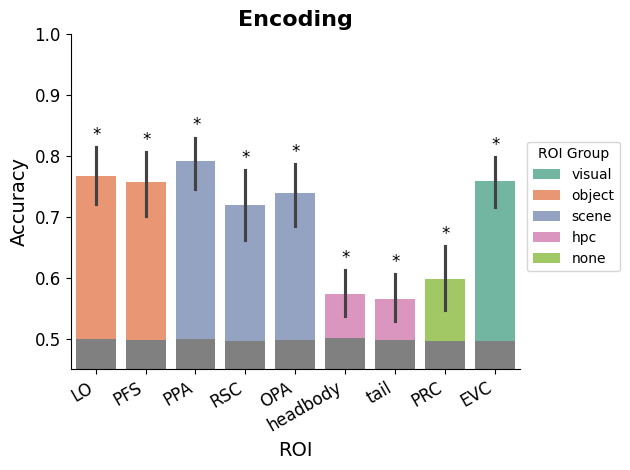

In [47]:
roi_order = ["LO", "PFS", "PPA", "RSC", "OPA", "headbody", "tail", "PRC", "EVC"]

ax = plt.subplot(111)
acc = sns.barplot(data=clf_df.query('phase == "E"'),
                  x="roi",
                  y="acc",
                  hue="roi_group",
                  hue_order=["visual", "object", "scene", "hpc", "none"],
                  order=roi_order,
                  palette="Set2",
                  ax=ax)

null = sns.barplot(data=clf_df.query('phase == "E"'),
                   x="roi",
                   y="shuff_acc",
                   color="gray",
                   order=roi_order,
                   errorbar=None,
                   ax=ax)

# one-tailed t-test against 0.5
pvals = []
for roi in roi_order:
    # get roi specific accuracy values
    roi_accs = clf_df.query('phase == "E" & roi == @roi').acc.values
    # one-tailed t test
    tstat, pval = ttest_1samp(roi_accs, popmean=0.5, alternative="greater")
    print(roi, np.round(np.mean(roi_accs),2), np.round(tstat,2), np.round(pval, 3))
    pvals.append(pval)

# multiple comparison correction
pvals_corrected = false_discovery_control(pvals)
print(pvals)

# mark significant ROIs
for line in acc.lines:
    ind = int(line.get_xdata()[0])
    height = line.get_ydata()[1]
    if pvals_corrected[ind] < 0.05:
        ax.text(ind-0.07, height+0.02, "*", color='black', va='center', fontsize=12)

plt.xlabel("ROI", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim([0.45,1])
plt.xticks(rotation=30, ha="right")
plt.tick_params(labelsize=12)
ax.spines[['right', 'top']].set_visible(False)

plt.title("Encoding", fontsize=16, fontweight="bold")
plt.legend(title='ROI Group', loc='upper left', bbox_to_anchor=(1, 0.7))
plt.tight_layout()
plt.show()

### Recall

LO 0.57 2.45 0.012
PFS 0.56 2.72 0.006
PPA 0.6 4.1 0.0
RSC 0.59 3.39 0.002
OPA 0.59 3.05 0.003
headbody 0.48 -0.92 0.817
tail 0.49 -0.33 0.628
PRC 0.53 1.5 0.075
EVC 0.58 2.91 0.004
[0.01741931 0.01165191 0.00230302 0.00692521 0.00934162 0.81682465
 0.70603682 0.09658843 0.00934162]


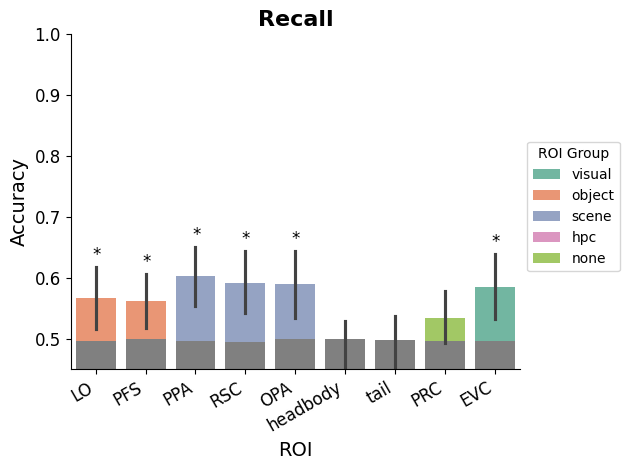

In [49]:
roi_order = ["LO", "PFS", "PPA", "RSC", "OPA", "headbody", "tail", "PRC", "EVC"]

ax = plt.subplot(111)
acc = sns.barplot(data=clf_df.query('phase == "R"'),
                  x="roi",
                  y="acc",
                  color="red",
                  hue="roi_group",
                  hue_order=["visual", "object", "scene", "hpc", "none"],
                  order=roi_order,
                  palette="Set2",
                  ax=ax)

null = sns.barplot(data=clf_df.query('phase == "R"'),
                   x="roi",
                   y="shuff_acc",
                   color="gray",
                   order=roi_order,
                   errorbar=None,
                   ax=ax)

# one-tailed t-test against 0.5
pvals = []
for roi in roi_order:
    # get roi specific accuracy values
    roi_accs = clf_df.query('phase == "R" & roi == @roi').acc.values
    # one-tailed t test
    tstat, pval = ttest_1samp(roi_accs, popmean=0.5, alternative="greater")
    print(roi, np.round(np.mean(roi_accs),2), np.round(tstat,2), np.round(pval, 3))
    pvals.append(pval)

# multiple comparison correction
pvals_corrected = false_discovery_control(pvals)
print(pvals_corrected)

# mark significant ROIs
for line in acc.lines:
    ind = int(line.get_xdata()[0])
    height = line.get_ydata()[1]
    if pvals_corrected[ind] < 0.05:
        ax.text(ind-0.07, height+0.02, "*", color='black', va='center', fontsize=12)

plt.xlabel("ROI", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim([0.45,1])
plt.xticks(rotation=30, ha="right")
plt.tick_params(labelsize=12)
ax.spines[['right', 'top']].set_visible(False)

plt.title("Recall", fontsize=16, fontweight="bold")
plt.legend(title='ROI Group', loc='upper left', bbox_to_anchor=(1, 0.7))
plt.tight_layout()
plt.show()

# RSA

## Memorability RDM

In [8]:
# memorability-based RDM
mem_rdm = np.zeros((len(ITEM_LIST), len(ITEM_LIST)))

for i in range(len(ITEM_LIST)):
    i_item = ITEM_LIST[i]
    i_mem = agg_mem_df.query('fine_level == @i_item')["mem_score"].values[0]

    for j in range(len(ITEM_LIST)):
        j_item = ITEM_LIST[j]
        j_mem = agg_mem_df.query('fine_level == @j_item')["mem_score"].values[0]

        # calculate the distance (just absolute difference here)
        mem_rdm[i,j] = np.abs(i_mem - j_mem)

# fisher's z transform
mem_rdm = np.arctanh(mem_rdm)

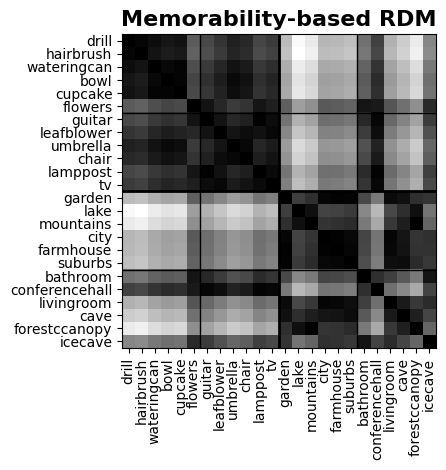

In [50]:
plt.subplot(111)

plt.imshow(np.tanh(mem_rdm), cmap="grey")
plt.xticks(np.arange(0,24), labels=ITEM_LIST, rotation=90)
plt.yticks(np.arange(0,24), labels=ITEM_LIST)

# coarse level (object vs scene)
plt.plot([-0.5,23.5], [11.5,11.5], color="k", linewidth=2)
plt.plot([11.5,11.5], [-0.5,23.5], color="k", linewidth=2)

# high level (big/small, open/closed)
plt.plot([-0.5,23.5], [5.5,5.5], color="k", linewidth=1)
plt.plot([-0.5,23.5], [17.5,17.5], color="k", linewidth=1)
plt.plot([5.5,5.5], [-0.5,23.5], color="k", linewidth=1)
plt.plot([17.5,17.5], [-0.5,23.5], color="k", linewidth=1)

plt.title("Memorability-based RDM", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Brain RDMs

In [13]:
def get_sub_roi_rdm(sub, roi, phase, y_label="fine_level"):
    # get data
    X, y = get_roi_data(sub, roi, phase, y_label)
    # split into odd/even trial data
    odd_X = X[:len(X)//2]
    even_X = X[len(X)//2:]
    # get available category labels
    y_labels = y[:len(y)//2]
    
    # subject level rdm 
    sub_rdm = np.zeros((len(ITEM_LIST), len(ITEM_LIST)))

    for i in range(len(ITEM_LIST)):
        for j in range(len(ITEM_LIST)):
            try:
                # find the corresponding indices
                i_ind = np.where(y_labels == ITEM_LIST[i])[0][0]
                j_ind = np.where(y_labels == ITEM_LIST[j])[0][0]
                # Pearson correlation
                odd_even_corr, odd_even_pval = pearsonr(odd_X[i_ind,:], even_X[j_ind,:])
                even_odd_corr, even_odd_pval = pearsonr(even_X[i_ind,:], odd_X[j_ind,:])
                # mean correlation value
                # mean_corr = np.mean([np.abs(odd_even_corr), np.abs(even_odd_corr)])
                mean_corr = np.mean([odd_even_corr, even_odd_corr])
                sub_rdm[i,j] = 1 - mean_corr
            except:
                # no condition data available
                sub_rdm[i,j] = np.nan
    
    return sub_rdm


def get_roi_rdms(sub_list, roi, phase):
    roi_rdm = np.zeros((len(sub_list), len(ITEM_LIST), len(ITEM_LIST)))
    for i, sub in enumerate(sub_list):
        sub_rdm = get_sub_roi_rdm(sub, roi, phase)
        # fisher's z transform
        roi_rdm[i,:,:] = np.arctanh(sub_rdm)

    return roi_rdm

In [14]:
# brain-based RDMs
roi_rdm_dict = {}
for roi in ROI_LABELS:
    phase_dict = {}
    
    for phase in ["E", "R"]:
        phase_dict[phase] = get_roi_rdms(sub_list, roi, phase)

    roi_rdm_dict[roi] = phase_dict

## Sample ROI RDMs

### Parahippocampal Place Area (PPA)

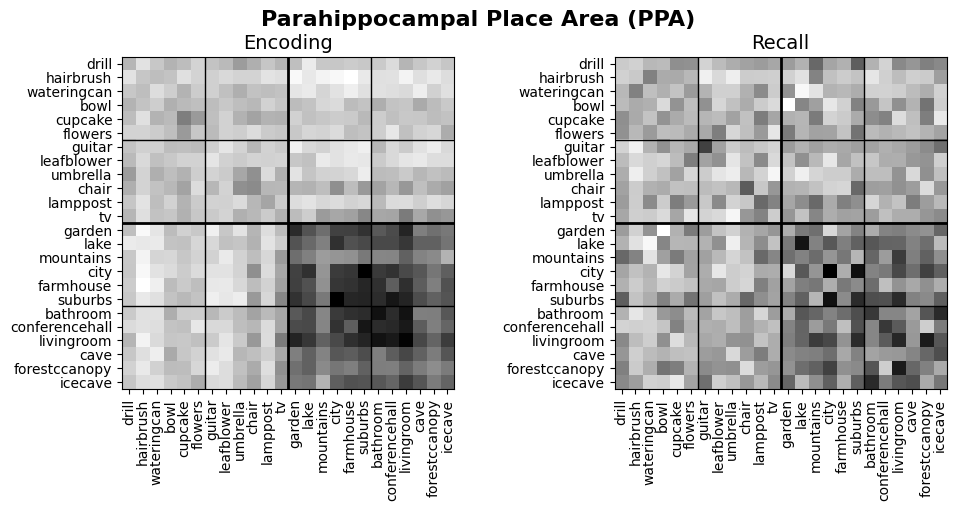

In [28]:
roi = "PPA"
phases = ["Encoding", "Recall"]

fig, axes = plt.subplots(ncols=2, figsize=(10,5))
for (ax, phase) in zip(axes, phases):
    # switch back to correlation for visualization
    rdms = roi_rdm_dict[roi][phase[0]]
    avg_rdm = np.tanh(np.nanmean(rdms, axis=0))
    ax.imshow(avg_rdm, cmap="grey")
    ax.set_xticks(np.arange(0,24), labels=ITEM_LIST, rotation=90)
    ax.set_yticks(np.arange(0,24), labels=ITEM_LIST)

    # coarse level (object vs scene)
    ax.plot([-0.5,23.5], [11.5,11.5], color="k", linewidth=2)
    ax.plot([11.5,11.5], [-0.5,23.5], color="k", linewidth=2)

    # high level (big/small, open/closed)
    ax.plot([-0.5,23.5], [5.5,5.5], color="k", linewidth=1)
    ax.plot([-0.5,23.5], [17.5,17.5], color="k", linewidth=1)
    ax.plot([5.5,5.5], [-0.5,23.5], color="k", linewidth=1)
    ax.plot([17.5,17.5], [-0.5,23.5], color="k", linewidth=1)

    ax.set_title(phase, fontsize=14)

plt.suptitle("Parahippocampal Place Area (PPA)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Lateral Occipital (LO)

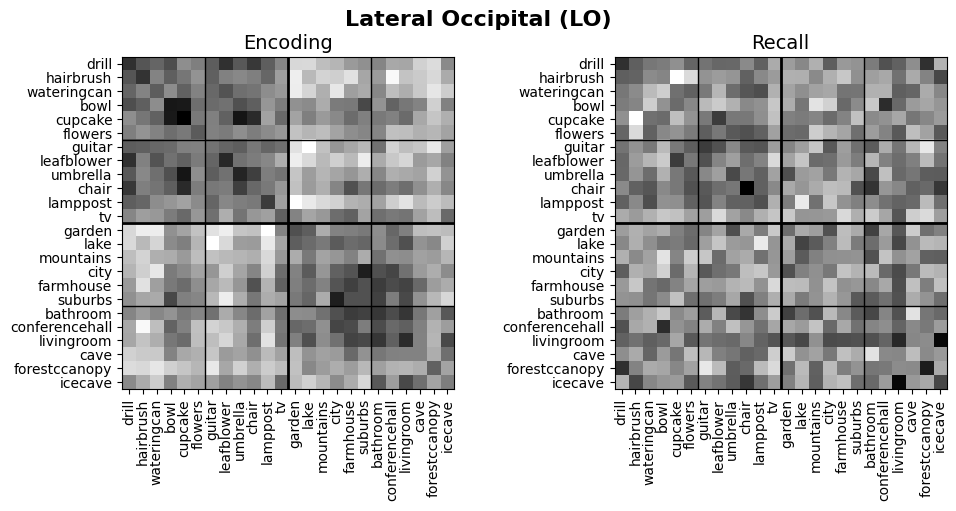

In [16]:
roi = "LO"
phases = ["Encoding", "Recall"]

fig, axes = plt.subplots(ncols=2, figsize=(10,5))
for (ax, phase) in zip(axes, phases):
    # switch back to correlation for visualization
    rdms = roi_rdm_dict[roi][phase[0]]
    avg_rdm = np.tanh(np.nanmean(rdms, axis=0))
    ax.imshow(avg_rdm, cmap="grey")
    ax.set_xticks(np.arange(0,24), labels=ITEM_LIST, rotation=90)
    ax.set_yticks(np.arange(0,24), labels=ITEM_LIST)

    # coarse level (object vs scene)
    ax.plot([-0.5,23.5], [11.5,11.5], color="k", linewidth=2)
    ax.plot([11.5,11.5], [-0.5,23.5], color="k", linewidth=2)

    # high level (big/small, open/closed)
    ax.plot([-0.5,23.5], [5.5,5.5], color="k", linewidth=1)
    ax.plot([-0.5,23.5], [17.5,17.5], color="k", linewidth=1)
    ax.plot([5.5,5.5], [-0.5,23.5], color="k", linewidth=1)
    ax.plot([17.5,17.5], [-0.5,23.5], color="k", linewidth=1)

    ax.set_title(phase, fontsize=14)

plt.suptitle("Lateral Occipital (LO)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Hippocampus Head-Body

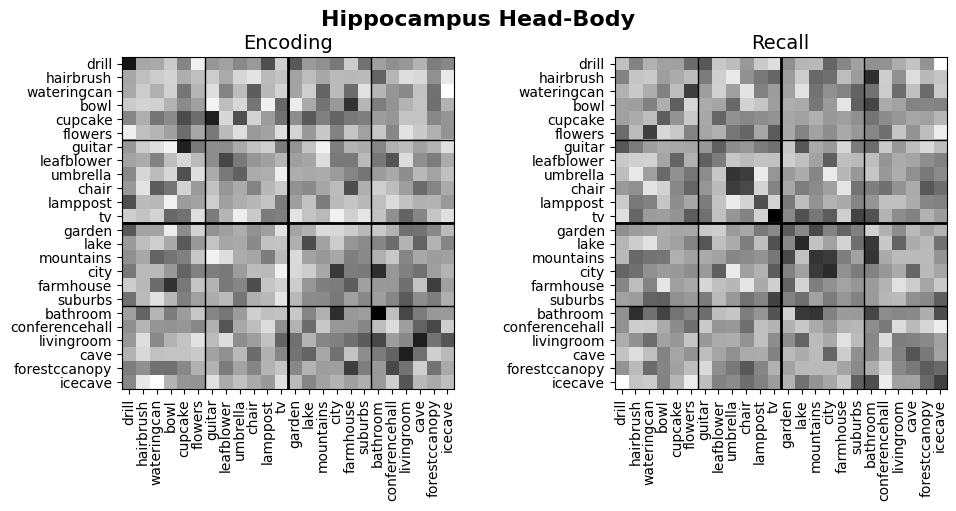

In [17]:
roi = "headbody"
phases = ["Encoding", "Recall"]

fig, axes = plt.subplots(ncols=2, figsize=(10,5))
for (ax, phase) in zip(axes, phases):
    # switch back to correlation for visualization
    rdms = roi_rdm_dict[roi][phase[0]]
    avg_rdm = np.tanh(np.nanmean(rdms, axis=0))
    ax.imshow(np.tanh(avg_rdm), cmap="grey")
    ax.set_xticks(np.arange(0,24), labels=ITEM_LIST, rotation=90)
    ax.set_yticks(np.arange(0,24), labels=ITEM_LIST)

    # coarse level (object vs scene)
    ax.plot([-0.5,23.5], [11.5,11.5], color="k", linewidth=2)
    ax.plot([11.5,11.5], [-0.5,23.5], color="k", linewidth=2)

    # high level (big/small, open/closed)
    ax.plot([-0.5,23.5], [5.5,5.5], color="k", linewidth=1)
    ax.plot([-0.5,23.5], [17.5,17.5], color="k", linewidth=1)
    ax.plot([5.5,5.5], [-0.5,23.5], color="k", linewidth=1)
    ax.plot([17.5,17.5], [-0.5,23.5], color="k", linewidth=1)

    ax.set_title(phase, fontsize=14)

plt.suptitle("Hippocampus Head-Body", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Relating Memorability RDMs to Brain RDMs

In [35]:
rdm_corr_df = pd.DataFrame(columns=["roi", "phase", "sub", "corr", "shuff_corr"])
SHUFFLE = False

# get lower half triangle values
lower_inds = np.tril_indices(mem_rdm.shape[0], k=-1)
mem_rdm_1d = mem_rdm[lower_inds]

# for every ROI
for roi in ROI_LABELS:
    for phase in ["E", "R"]:
        # get corresponding rdm
        brain_rdms = roi_rdm_dict[roi][phase]

        for i in range(brain_rdms.shape[0]):
            # only get lower half triangle values
            brain_rdm_1d = brain_rdms[i][lower_inds]
            # Spearman's rank correlation
            corr, _ = spearmanr(mem_rdm_1d, brain_rdm_1d, nan_policy='omit')
            
            if SHUFFLE:
                # for null distribution
                def do_permutation():
                    shuff_1d = brain_rdm_1d.copy()
                    np.random.shuffle(shuff_1d)
                    # Spearman's rank correlation
                    corr, _ = spearmanr(mem_rdm_1d, shuff_1d, nan_policy='omit')
                    return corr

                parallel,p_func,_ = parallel_func(do_permutation, n_jobs=-1, verbose=False)
                shuff_corrs = parallel(p_func() for i in range(100))
                avg_shuff_corrs = np.mean(np.abs(shuff_corrs))
            else:
                avg_shuff_corrs = 0.05

            # save
            rdm_corr_df.loc[len(rdm_corr_df)] = [roi, phase, i+1, abs(corr), avg_shuff_corrs]

In [36]:
roi_dict = {"visual": ["EVC"],
            "object": ["LO", "PFS"],
            "scene": ["PPA", "RSC", "OPA"],
            "hpc": ["headbody", "tail"]
            }

def assign_roi_group(row):
    curr_roi = row["roi"]

    for group, roi_list in roi_dict.items():
        if curr_roi in roi_list:
            return group
    
    return "none"

rdm_corr_df["roi_group"] = rdm_corr_df.apply(assign_roi_group, axis=1)
# rdm_corr_df.to_csv("./data/rdm_corr_df.csv")
rdm_corr_df

,roi,phase,sub,corr,shuff_corr,roi_group
0,LO,E,1,0.033511,0.05,object
1,LO,E,2,0.155311,0.05,object
2,LO,E,3,0.209334,0.05,object
3,LO,E,4,0.113179,0.05,object
4,LO,E,5,0.062370,0.05,object
...,...,...,...,...,...,...
391,EVC,R,18,0.078513,0.05,visual
392,EVC,R,19,0.057147,0.05,visual
393,EVC,R,20,0.055638,0.05,visual
394,EVC,R,21,0.152165,0.05,visual


LO 0.29 8.23 0.0
PFS 0.27 5.76 0.0
PPA 0.23 6.89 0.0
RSC 0.19 5.07 0.0
OPA 0.21 6.17 0.0
headbody 0.05 0.59 0.281
tail 0.08 2.67 0.0071
PRC 0.12 3.42 0.0014
EVC 0.26 5.56 0.0
[2.35772846e-07 1.15850191e-05 1.85482075e-06 5.10507173e-05
 9.48927593e-06 2.80999964e-01 8.01660475e-03 1.75495087e-03
 1.44560045e-05]


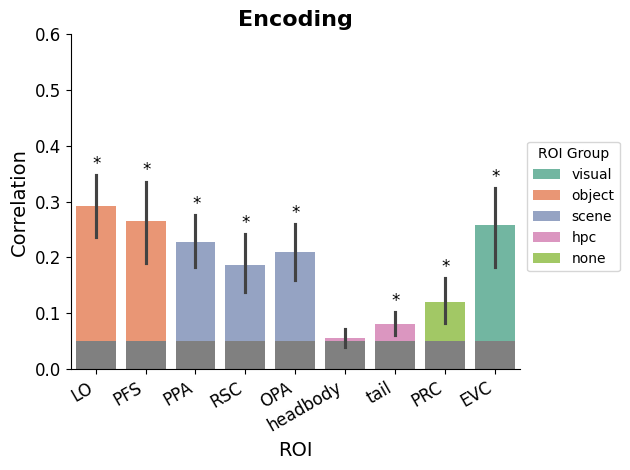

In [53]:
phase = "E"
roi_order = ["LO", "PFS", "PPA", "RSC", "OPA", "headbody", "tail", "PRC", "EVC"]

ax = plt.subplot(111)
g = sns.barplot(data=rdm_corr_df.query('phase == @phase'),
            x="roi",
            y="corr",
            hue="roi_group",
            hue_order=["visual", "object", "scene", "hpc", "none"],
            order=roi_order,
            palette="Set2",
            ax=ax
            )

null = sns.barplot(data=rdm_corr_df.query('phase == @phase'),
                   x="roi",
                   y="shuff_corr",
                   color="grey",
                   order=roi_order,
                   errorbar=None,
                   ax=ax
                   )

# significance testing
pvals = []
for roi in roi_order:
    curr_roi_corrs = rdm_corr_df.query('roi == @roi & phase == @phase')["corr"].values
    tstat, pval = ttest_1samp(curr_roi_corrs, popmean=0.05, nan_policy="omit", alternative="greater")
    print(roi, np.round(np.nanmean(curr_roi_corrs), 2), np.round(tstat, 2), np.round(pval, 4))
    pvals.append(pval)

# multiple comparison correction
pvals_corrected = false_discovery_control(pvals)
print(pvals_corrected)
    
# mark significant ROIs
for line in g.lines:
    ind = int(line.get_xdata()[0])
    height = line.get_ydata()[1]
    if pvals_corrected[ind] < 0.05:
        ax.text(ind-0.07, height+0.02, "*", color='black', va='center', fontsize=12)

ax.spines[['right', 'top']].set_visible(False)
plt.xlabel("ROI", fontsize=14)
plt.ylabel("Correlation", fontsize=14)
plt.tick_params(labelsize=12)
plt.ylim([0, 0.6])
plt.xticks(rotation=30, ha="right")

plt.title("Encoding", fontsize=16, fontweight="bold")
plt.legend(title='ROI Group', loc='upper left', bbox_to_anchor=(1, 0.7))
plt.tight_layout()
plt.show()

LO 0.09 2.98 0.0036
PFS 0.11 2.83 0.005
PPA 0.09 3.46 0.0012
RSC 0.1 4.05 0.0003
OPA 0.07 1.2 0.1233
headbody 0.06 1.12 0.1384
tail 0.06 0.83 0.2073
PRC 0.07 1.27 0.1094
EVC 0.06 1.96 0.0314
[0.01072775 0.01116074 0.00527013 0.00305831 0.15569678 0.15569678
 0.20732385 0.15569678 0.05654148]


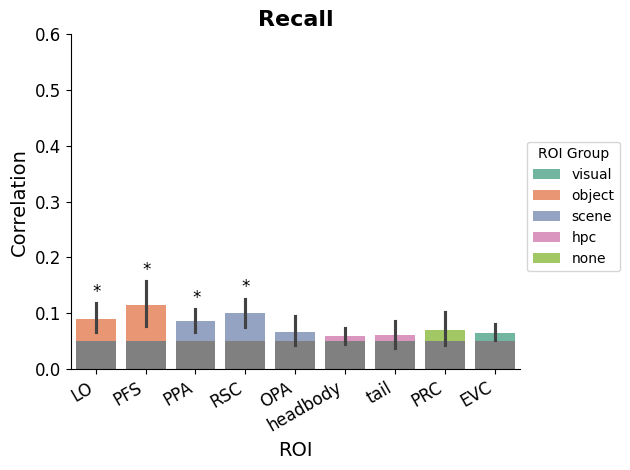

In [54]:
phase = "R"
roi_order = ["LO", "PFS", "PPA", "RSC", "OPA", "headbody", "tail", "PRC", "EVC"]

ax = plt.subplot(111)
g = sns.barplot(data=rdm_corr_df.query('phase == @phase'),
            x="roi",
            y="corr",
            hue="roi_group",
            hue_order=["visual", "object", "scene", "hpc", "none"],
            order=roi_order,
            palette="Set2",
            ax=ax
            )

null = sns.barplot(data=rdm_corr_df.query('phase == @phase'),
                   x="roi",
                   y="shuff_corr",
                   color="grey",
                   order=roi_order,
                   errorbar=None,
                   ax=ax
                   )

# significance testing
pvals = []
for roi in roi_order:
    curr_roi_corrs = rdm_corr_df.query('roi == @roi & phase == @phase')["corr"].values
    tstat, pval = ttest_1samp(curr_roi_corrs, popmean=0.05, nan_policy="omit", alternative="greater")
    print(roi, np.round(np.nanmean(curr_roi_corrs), 2), np.round(tstat, 2), np.round(pval, 4))
    pvals.append(pval)

# multiple comparison correction
pvals_corrected = false_discovery_control(pvals)
print(pvals_corrected)
    
# mark significant ROIs
for line in g.lines:
    ind = int(line.get_xdata()[0])
    height = line.get_ydata()[1]
    if pvals_corrected[ind] < 0.05:
        ax.text(ind-0.07, height+0.02, "*", color='black', va='center', fontsize=12)

ax.spines[['right', 'top']].set_visible(False)
plt.xlabel("ROI", fontsize=14)
plt.ylabel("Correlation", fontsize=14)
plt.tick_params(labelsize=12)
plt.ylim([0, 0.6])
plt.xticks(rotation=30, ha="right")

plt.title("Recall", fontsize=16, fontweight="bold")
plt.legend(title='ROI Group', loc='upper left', bbox_to_anchor=(1, 0.7))
plt.tight_layout()
plt.show()